# Dataset-wise Excel Table Visualization

첨부 표의 점수를 데이터셋별로 시각화합니다.

- 좌측: `FeaturedMoE`
- 중앙: `Traditional models` (`SASRec`, `GRU4Rec`, `SR-GNN`, `Caser`)
- 우측: `Recent models` (`FAME`, `BSARec`, `FENRec`, `SIGMA`, `MSSR`, `Patt`)


In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

featured_model = ['FMoE']
traditional_models = ['SASRec', 'GRU4Rec', 'SR-GNN']
recent_models = ['FAME', 'BSARec', 'FENRec', 'SIGMA', 'Patt']
all_models = featured_model + traditional_models + recent_models

data = {
    'KuaiRec_0.2': {
        'FMoE': 0.0811, 'SASRec': 0.0785, 'GRU4Rec': 0.0775, 'SR-GNN': 0.0694, 
        'FAME': 0.0792, 'BSARec': 0.0789, 'FENRec': 0.0778, 'SIGMA': 0.0800, 'Patt': 0.0790,
    },
    'Last.fm_0.03': {
        'FMoE': 0.4076, 'SASRec': 0.4020, 'GRU4Rec': 0.3797, 'SR-GNN': 0.3988, 
        'FAME': 0.3949, 'BSARec': 0.3978, 'FENRec': 0.4038, 'SIGMA': 0.4032, 'Patt': 0.4009,
    },
}

group_specs = [
    ('FeaturedMoE', featured_model, {'FMoE': '#1f77b4'}),
    ('Traditional Models', traditional_models, {
        'SASRec': '#2ca25f',
        'GRU4Rec': '#41ab5d',
        'SR-GNN': '#66c2a4',
        'Caser': '#238b45',
    }),
    ('Recent Models', recent_models, {
        'FAME': '#f16913',
        'BSARec': '#fd8d3c',
        'FENRec': '#fdae6b',
        'SIGMA': '#e6550d',
        'MSSR': '#fdd0a2',
        'Patt': '#d94801',
    }),
]


def _y_limits(values: list[float]) -> tuple[float, float]:
    v_max = max(values)
    v_min = min(values)
    pad_top = max(0.01, v_max * 0.03)
    y_min = max(0.0, v_min - max(0.00005, (v_max - v_min) * 0.03))
    y_max = v_max + pad_top
    if y_max <= y_min:
        y_max = y_min + 0.05
    return y_min, y_max


def plot_dataset(dataset_name: str) -> None:
    row = data[dataset_name]

    x_positions = []
    labels = []
    values = []
    colors = []
    group_ranges = []

    x_cursor = 0.0
    gap = 0.55

    for group_name, models, palette in group_specs:
        available = [(m, row[m]) for m in models if row[m] is not None]
        if not available:
            continue

        start = x_cursor
        for model, value in available:
            x_positions.append(x_cursor)
            labels.append(model)
            values.append(value)
            colors.append(palette.get(model, '#999999'))
            x_cursor += 1.0
        end = x_cursor - 1.0

        group_ranges.append((group_name, start, end))
        x_cursor += gap

    if not values:
        print(f'{dataset_name}: no available values to plot')
        return

    y_min, y_max = _y_limits(values)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4.8), constrained_layout=True)
    bars = ax.bar(
        x_positions,
        values,
        color=colors,
        width=0.78,
        edgecolor='#f5f5f5',
        linewidth=1.1,
        zorder=3,
    )

    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=25)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.set_ylabel('Score')

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (y_max - y_min) * 0.012,
            f'{value:.4f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )

    for idx, (group_name, start, end) in enumerate(group_ranges):
        center = (start + end) / 2
        ax.text(
            center,
            y_max - (y_max - y_min) * 0.02,
            group_name,
            ha='center',
            va='top',
            fontsize=10,
            fontweight='bold',
            color='#444444',
        )

        if idx < len(group_ranges) - 1:
            next_start = group_ranges[idx + 1][1]
            sep_x = (end + next_start) / 2
            ax.axvline(sep_x, color='#777777', linestyle='--', linewidth=1.2, alpha=0.85)

    ax.set_title(f'{dataset_name} | Model Score Comparison', fontsize=13, fontweight='bold')
    plt.show()


def plot_fmoe_vs_sasrec() -> None:
    datasets = []
    fmoe_scores = []
    sasrec_scores = []

    for ds, row in data.items():
        if row.get('FMoE') is not None and row.get('SASRec') is not None:
            datasets.append(ds)
            fmoe_scores.append(row['FMoE'])
            sasrec_scores.append(row['SASRec'])

    x = np.arange(len(datasets))
    width = 0.36

    y_min, y_max = _y_limits(fmoe_scores + sasrec_scores)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5), constrained_layout=True)
    bars1 = ax.bar(x - width / 2, fmoe_scores, width, label='FMoE', color='#1f77b4', edgecolor='white')
    bars2 = ax.bar(x + width / 2, sasrec_scores, width, label='SASRec', color='#2ca25f', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('Score')
    ax.set_title('FMoE vs SASRec by Dataset', fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.legend(frameon=False)

    for bars in [bars1, bars2]:
        for b in bars:
            v = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, v + (y_max - y_min) * 0.012, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

    plt.show()


def plot_aggregated_models_excluding_sparse() -> None:
    core_datasets = ['Amazon', 'Movielens', 'Foursquare', 'Retail']
    df_core = pd.DataFrame.from_dict({k: data[k] for k in core_datasets}, orient='index')[all_models]

    raw_mean = df_core.mean(axis=0, skipna=True)
    norm_df = df_core.div(df_core.max(axis=1), axis=0)
    norm_mean = norm_df.mean(axis=0, skipna=True)

    order = raw_mean.sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    axes[0].bar(order, raw_mean[order], color=['#1f77b4' if m == 'FMoE' else '#4c9f70' if m in traditional_models else '#e67e22' for m in order], edgecolor='white')
    axes[0].set_title('Aggregated Mean Score (Amazon/Movielens/Foursquare/Retail)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean score')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', linestyle='--', alpha=0.25)

    axes[1].bar(order, norm_mean[order], color=['#1f77b4' if m == 'FMoE' else '#4c9f70' if m in traditional_models else '#e67e22' for m in order], edgecolor='white')
    axes[1].set_title('Aggregated Mean Relative Score (dataset-max normalized)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean relative score')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', linestyle='--', alpha=0.25)

    plt.show()



In [3]:
df = pd.DataFrame.from_dict(data, orient='index')[all_models]
df


,FMoE,SASRec,GRU4Rec,SR-GNN,FAME,BSARec,FENRec,SIGMA,Patt
KuaiRec_0.2,0.0811,0.0785,0.0775,0.0694,0.0792,0.0789,0.0778,0.0800,0.0790
Last.fm_0.03,0.4076,0.4020,0.3797,0.3988,0.3949,0.3978,0.4038,0.4032,0.4009


## Kuai


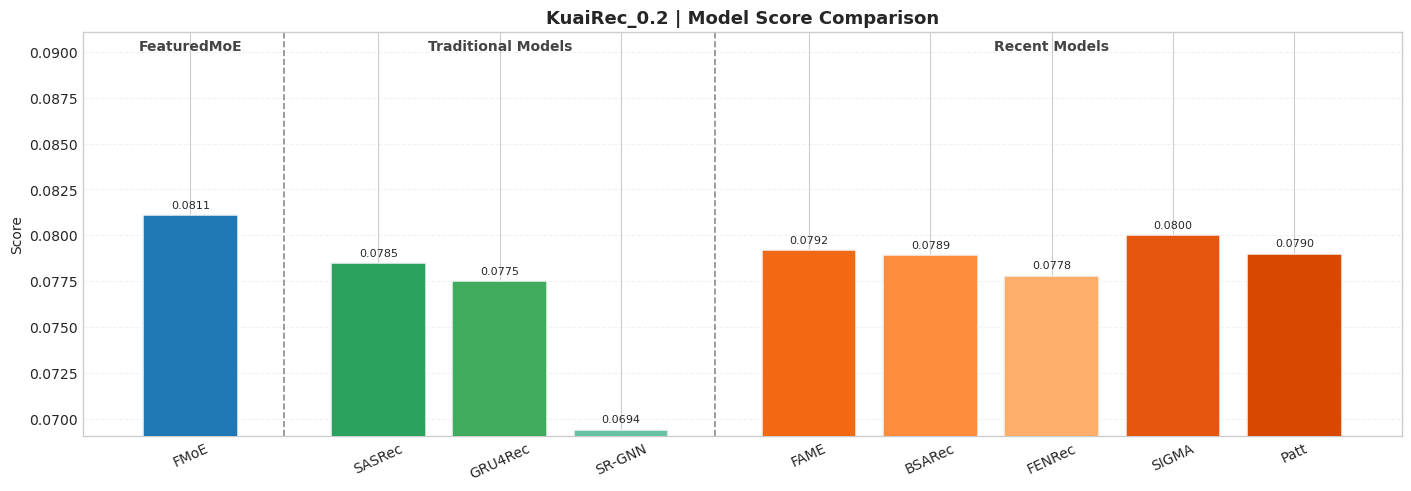

In [4]:
plot_dataset('KuaiRec_0.2')


## last.fm


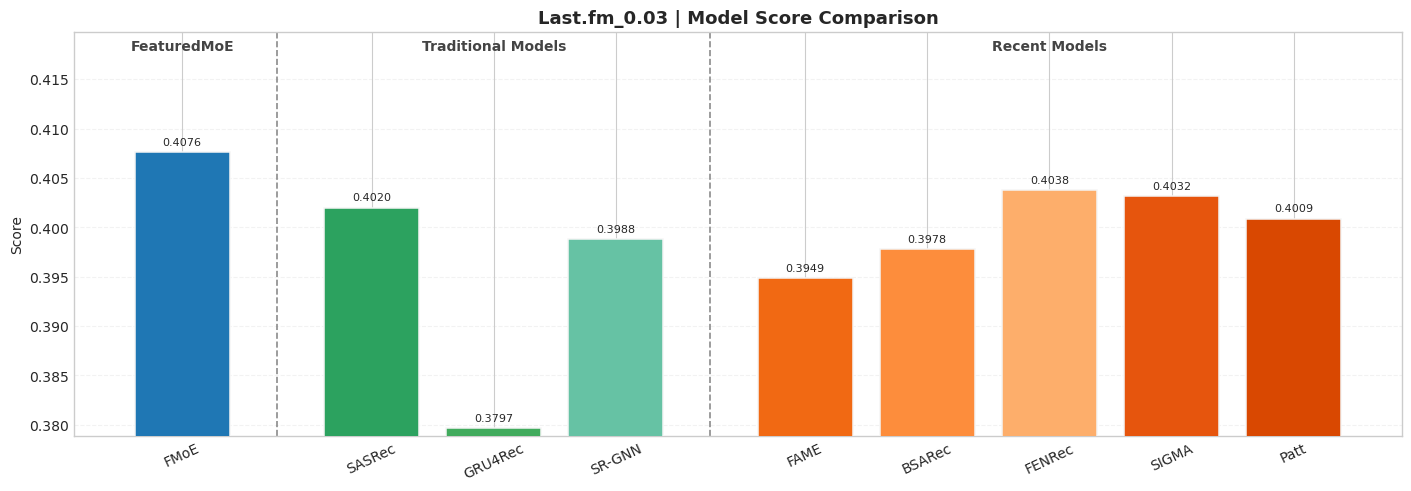

In [5]:
plot_dataset('Last.fm_0.03')


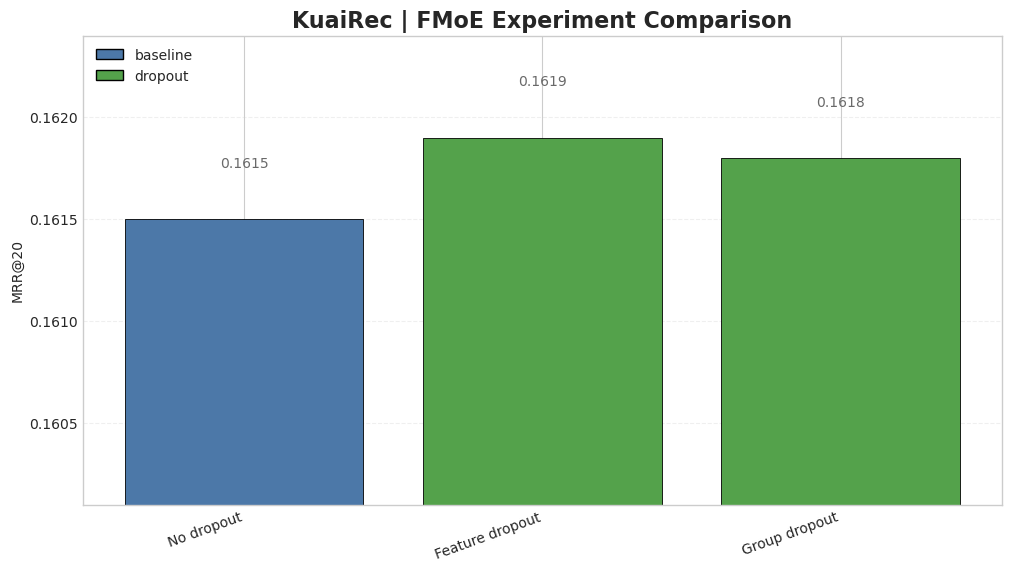

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Edit this list for each presentation / experiment sweep.
experiment_rows = [
    {'label': 'No dropout', 'score': 0.1615, 'group': 'baseline'},
    {'label': 'Feature dropout', 'score': 0.1619, 'group': 'dropout'},
    {'label': 'Group dropout', 'score': 0.1618, 'group': 'dropout'},
]

title = 'KuaiRec | FMoE Experiment Comparison'
metric_name = 'MRR@20'
sort_by_score = False  # True if you want descending bars.

group_colors = {
    'baseline': '#4c78a8',
    'dropout': '#54a24b',
    'serial': '#54a24b',
    'parallel': '#2d4aa8',
    'fmoe': '#f58518',
    'stage': '#f58518',
    'group': '#54a24b',
    'mixed': '#2d4aa8',
    'gated_bias': '#54a24b',
    'Prototype': '#d2dfdd',
}

exp_df = pd.DataFrame(experiment_rows)
if sort_by_score:
    exp_df = exp_df.sort_values('score', ascending=False).reset_index(drop=True)

colors = [group_colors.get(g, '#9e9e9e') for g in exp_df['group']]
fig, ax = plt.subplots(figsize=(max(10, len(exp_df) * 1.15), 5.6), constrained_layout=True)
bars = ax.bar(exp_df['label'], exp_df['score'], color=colors, edgecolor='black', linewidth=0.6)

vmin = float(exp_df['score'].min())
vmax = float(exp_df['score'].max())
ypad = max(0.004, (vmax - vmin) * 0.025 if vmax > vmin else 0.001)
ax.set_ylim(max(0.0, vmin - ypad * 0.35), vmax + 0.0005)#ypad)
ax.set_title(title, fontsize=16, weight='bold')
ax.set_ylabel(metric_name)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=20, ha='right')

for bar, score in zip(bars, exp_df['score']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ypad * 0.06,
        f'{score:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='dimgray',
    )

legend_items = [
    Patch(facecolor=color, edgecolor='black', label=group)
    for group, color in group_colors.items()
    if group in set(exp_df['group'])
]
if legend_items:
    ax.legend(handles=legend_items, frameon=False, loc='upper left')

plt.show()
